[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/14-matplotlib-bases.ipynb)

# Matplotlib

Matplotlib est la bibliothèque standard pour faire des graphiques en Python.
En machine learning, elle sert en permanence : regarder ses données avant
d'entraîner un modèle, tracer une courbe d'erreur, afficher une matrice de
confusion.

## Comment utiliser ce notebook

Les cellules sont à exécuter dans l'ordre. Chaque partie suit le même schéma :
une explication, le code correspondant, et parfois une piste à tester soi-même.

Les sections intitulées "Piège" signalent les erreurs classiques, celles qui
font perdre du temps quand on ne les connaît pas.

Prérequis : savoir manipuler des tableaux NumPy (`np.array`, `np.linspace`).
Aucune connaissance de Matplotlib n'est nécessaire.

## 1. Préparer des données à tracer

Matplotlib ne trace pas des fonctions mathématiques : il trace des points, puis
il les relie par des segments de droite. La distinction a des conséquences
concrètes, on va le vérifier tout de suite.

Il faut donc deux tableaux NumPy :

- `x` : les abscisses, réparties régulièrement grâce à `np.linspace`
- `y` : les ordonnées, calculées à partir de `x`

`np.linspace(début, fin, nombre_de_points)` génère un tableau de valeurs
régulièrement espacées entre `début` et `fin`, bornes comprises.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(0, 2, 10) # 10 points entre 0 et 2
y = x**2 # élève chaque élément au carré
print("x =", x)
print("y =", y)
print("Forme de x :", x.shape)

x = [0.         0.22222222 0.44444444 0.66666667 0.88888889 1.11111111
 1.33333333 1.55555556 1.77777778 2.        ]
y = [0.         0.04938272 0.19753086 0.44444444 0.79012346 1.2345679
 1.77777778 2.41975309 3.16049383 4.        ]
Forme de x : (10,)


### À tester : combien de points faut-il ?

La cellule suivante trace la même parabole avec 5, 10 et 100 points. Avec peu de
points, la courbe est en réalité une ligne brisée : Matplotlib relie les points
entre eux, il ne devine rien de la fonction mathématique.

C'est la première chose à retenir.

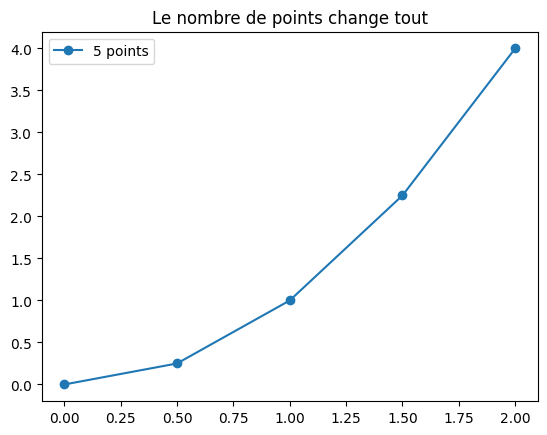

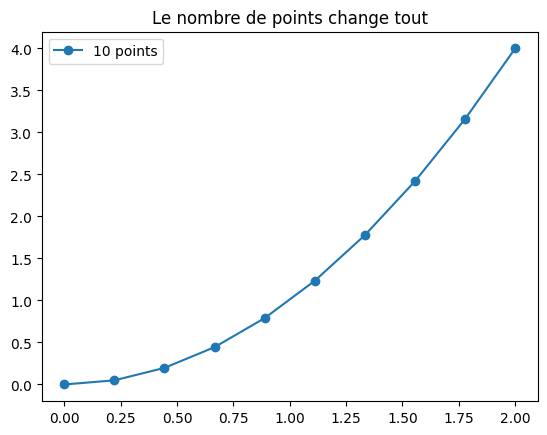

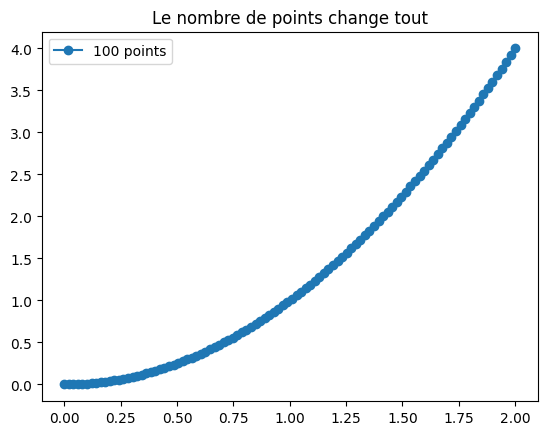

In [ ]:
for n in [5, 10, 100]:
  x_test = np.linspace(0, 2, n)
  plt.plot(x_test, x_test**2, marker='o', label= f'{n} points') # marker='o' permet d'afficher un cercle sur chaque point de la courbe
  plt.legend()
  plt.title("Le nombre de points change tout")
  plt.show()

## 2. Les deux graphiques de base : plot et scatter

| Fonction | Ce qu'elle fait | Quand l'utiliser |
|---|---|---|
| `plt.plot(x, y)` | trace des points reliés par des segments | une évolution continue : une courbe, une série temporelle |
| `plt.scatter(x, y)` | trace des points isolés | un nuage de points, des observations indépendantes |

En machine learning, `scatter` sert à visualiser un jeu de données, où chaque
point représente un individu. `plot` sert plutôt à tracer une courbe : la
fonction apprise par le modèle, l'évolution de l'erreur au fil de
l'entraînement.

`plt.show()` affiche la figure et la referme. Dans Jupyter on peut souvent
l'omettre, mais on verra plus bas pourquoi c'est une mauvaise habitude.

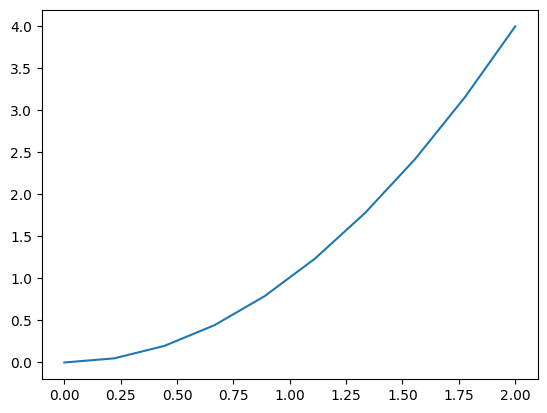

In [ ]:
plt.plot(x,y)
plt.show()

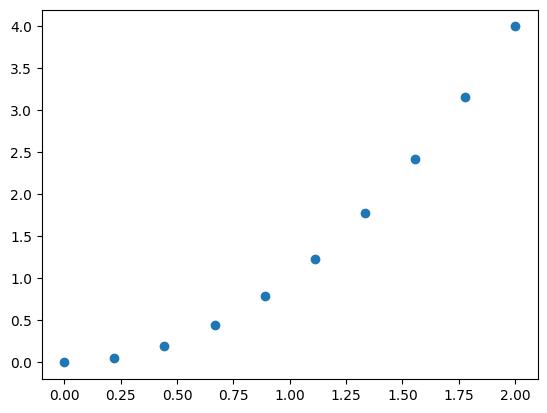

In [ ]:
plt.scatter(x,y)
plt.show()

## 3. Personnaliser l'apparence

`plot` accepte de nombreux arguments optionnels. Les trois plus utiles :

| Argument | Abréviation | Rôle | Exemples de valeurs |
|---|---|---|---|
| `color` | `c` | la couleur | `'blue'`, `'red'`, `'#2ecc71'` |
| `linewidth` | `lw` | l'épaisseur du trait | `1`, `2`, `5` |
| `linestyle` | `ls` | le style du trait | `'solid'`, `'dashed'`, `'dashdot'`, `'dotted'` |

Les abréviations sont pratiques quand on explore, mais dans un notebook destiné
à être lu, les noms complets se comprennent mieux.

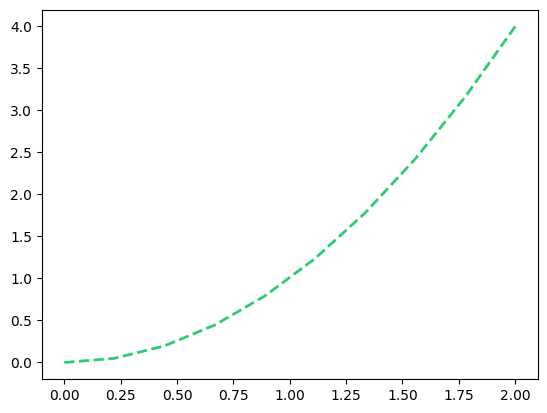

In [ ]:
plt.plot(x, y, color='#2ecc71', linewidth=2, linestyle='dashed')
plt.show()

### À tester : comparer tous les styles d'un coup

Plutôt que de relancer la cellule en changeant une valeur à chaque fois, une
boucle permet de tout voir sur une seule figure. On décale chaque courbe
verticalement avec `+ i` pour qu'elles ne se superposent pas.

In [ ]:
styles = ['solid', 'dashed', 'dashdot', 'dotted']
print(list(enumerate(styles)))

[(0, 'solid'), (1, 'dashed'), (2, 'dashdot'), (3, 'dotted')]


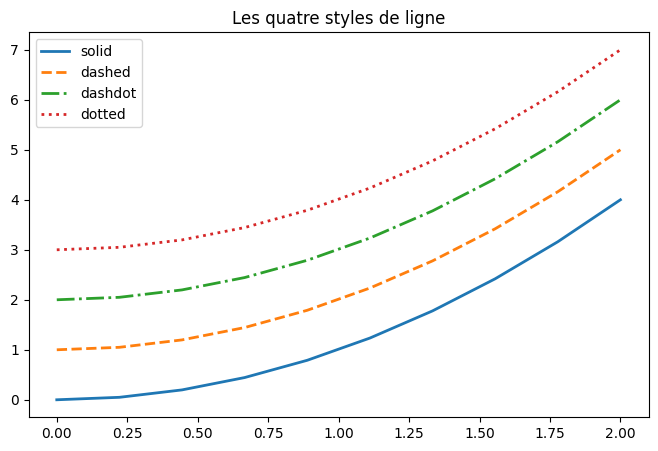

In [ ]:
styles = ['solid', 'dashed', 'dashdot', 'dotted']
plt.figure(figsize=(8, 5))
for i, style in enumerate(styles):
  plt.plot(x, y + i, linestyle=style, linewidth=2, label=style)
plt.legend()
plt.title("Les quatre styles de ligne")
plt.show()

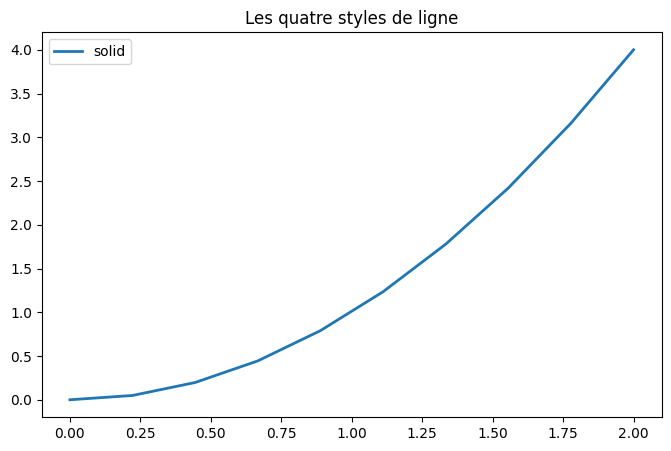

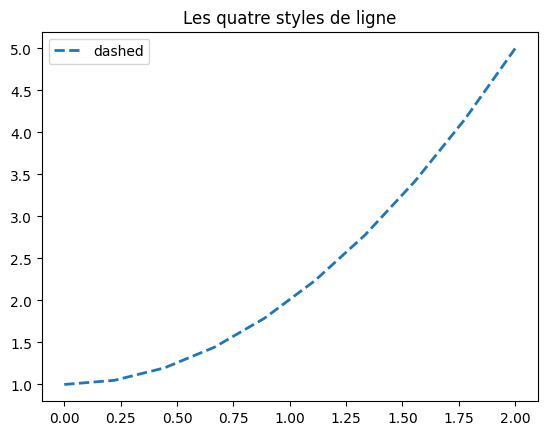

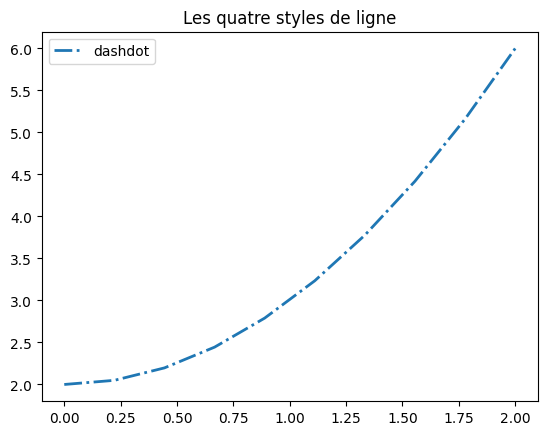

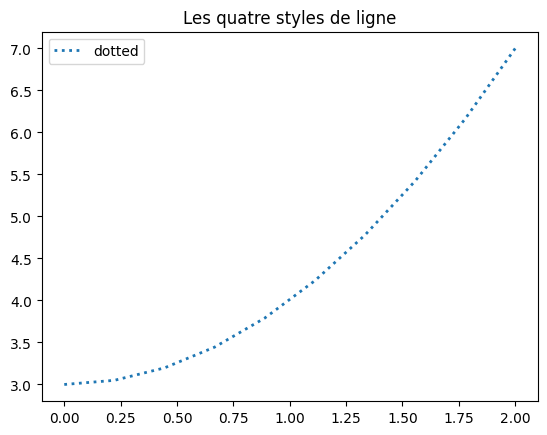

In [ ]:
styles = ['solid', 'dashed', 'dashdot', 'dotted']
plt.figure(figsize=(8, 5))
for i, style in enumerate(styles):
  plt.plot(x, y + i, linestyle=style, linewidth=2, label=style)
  plt.legend()
  plt.title("Les quatre styles de ligne")
  plt.show()

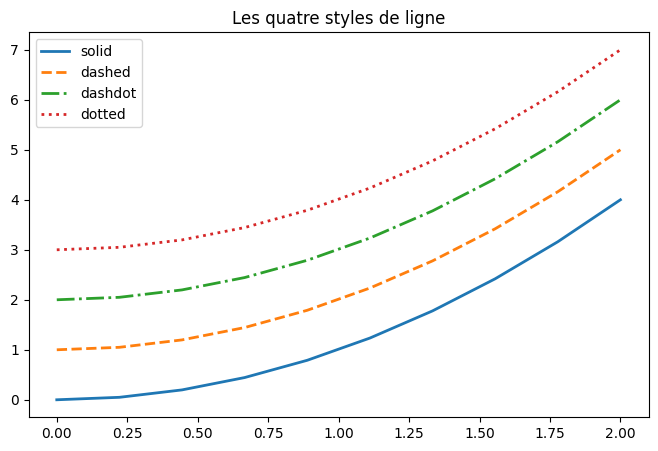

In [ ]:
styles = ['solid', 'dashed', 'dashdot', 'dotted']
decalage = 0

plt.figure(figsize=(8, 5))

for style in styles:
    plt.plot(x, y + decalage, linestyle=style, linewidth=2, label=style)
    decalage = decalage + 1

plt.legend()
plt.title("Les quatre styles de ligne")
plt.show()

À tester aussi : que se passe-t-il avec `linewidth=20` ? Et avec une couleur qui
n'existe pas, comme `color='bleu'` ? Lis le message d'erreur en entier. Savoir
décoder les erreurs de Matplotlib fait gagner beaucoup de temps par la suite.

## 4. Le cycle de vie d'une figure

C'est la partie la plus importante du cours. Une figure Matplotlib se construit
par étapes successives, dans un ordre qui a son importance :

```
1. plt.figure()      on crée une figure vide, et on choisit sa taille
2. plt.plot(...)     on y ajoute une ou plusieurs courbes
3. plt.title(...)    on l'habille : titre, noms des axes, légende
   plt.xlabel(...)
   plt.ylabel(...)
   plt.legend()
4. plt.savefig(...)  on l'enregistre, avant show()
5. plt.show()        on l'affiche, et Matplotlib la referme
```

Chaque appel s'applique à la figure courante. Tant qu'on n'a pas appelé `show()`,
on continue de travailler sur la même.

`plt.figure(figsize=(largeur, hauteur))` définit la taille en pouces. C'est
souvent la première chose à régler, la taille par défaut étant assez petite.

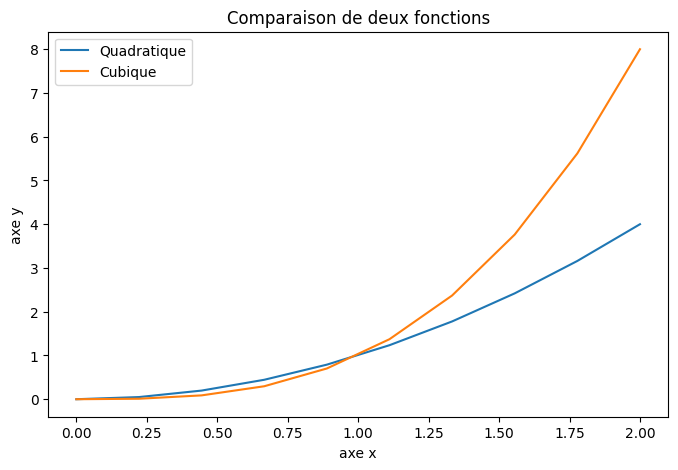

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(x, y,    label='Quadratique') # le label sert à la légende
plt.plot(x, x**3, label='Cubique')
plt.title('Comparaison de deux fonctions')
plt.xlabel('axe x')
plt.ylabel('axe y')
plt.legend() # sans cet appel, les labels ne s'affichent pas
plt.show()

### Piège n°1 : legend() est obligatoire

Mettre `label='...'` dans `plot` ne suffit pas. Le label est simplement
enregistré, c'est `plt.legend()` qui dessine le cadre de légende. Si les labels
sont là mais qu'aucune légende n'apparaît, c'est presque toujours l'explication.

### Piège n°2 : savefig doit venir avant show

C'est l'erreur la plus fréquente, et la plus vicieuse, parce qu'elle passe
inaperçue : la figure s'affiche normalement dans le notebook, mais le fichier
enregistré est entièrement blanc.

La raison tient au comportement de `plt.show()`, qui affiche la figure puis la
vide de la mémoire. Après `show()`, la figure courante ne contient plus rien, et
c'est ce vide qui est sauvegardé.

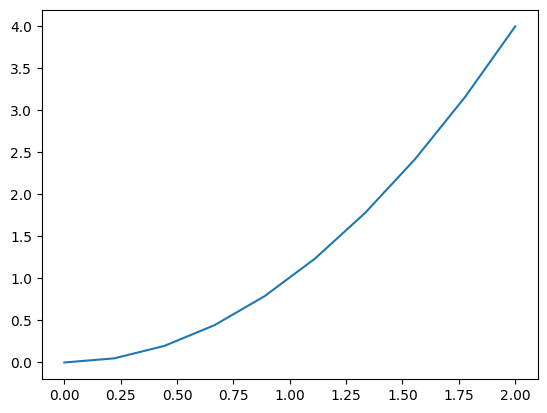

<Figure size 640x480 with 0 Axes>

In [ ]:
# Mauvais, le fichier produit sera vide
plt.plot(x, y)
plt.show()
plt.savefig('figure_vide.png')

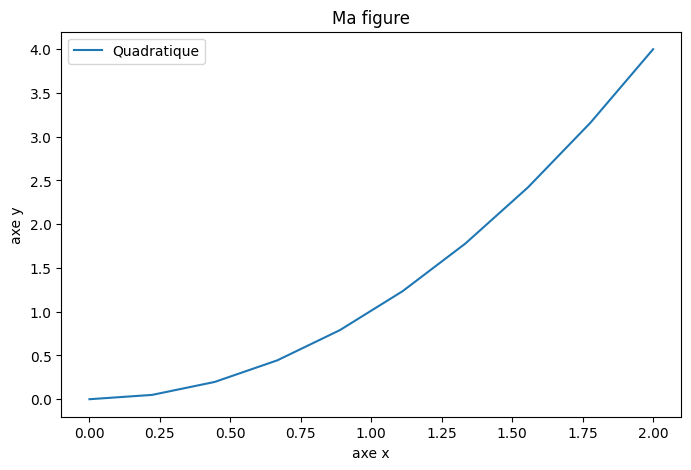

In [ ]:
# Bon, on enregistre, puis on affiche
plt.figure(figsize=(8, 5))
plt.plot(x, y, label='Quadratique')
plt.title('Ma figure')
plt.xlabel('axe x')
plt.ylabel('axe y')
plt.legend()
plt.savefig('figure.png', dpi=150, bbox_inches='tight')
# dpi=150 : définit la résolution de l'image
# bbox_inches='tight' : réduit les espaces blancs inutiles autour du graphique
plt.show()

Deux arguments utiles pour `savefig` :

- `dpi=150` fixe la résolution. La valeur par défaut est 72, ce qui est faible
  pour un rapport ou une présentation.
- `bbox_inches='tight'` rogne les marges blanches inutiles autour du graphique.

À vérifier : exécute les deux cellules ci-dessus, puis ouvre les deux fichiers
PNG produits. Constater soi-même le fichier blanc est le meilleur moyen de ne
plus jamais faire l'erreur.

## 5. Plusieurs graphiques dans une même figure : subplot

`plt.subplot(nb_lignes, nb_colonnes, position)` découpe la figure en une grille
et sélectionne une case. Tout ce qu'on trace ensuite va dans cette case, jusqu'au
prochain appel à `subplot`.

Attention, la position se compte à partir de 1 et non de 0, et la grille se
parcourt de gauche à droite puis de haut en bas.

```
subplot(2, 2, 1)   subplot(2, 2, 2)
subplot(2, 2, 3)   subplot(2, 2, 4)
```

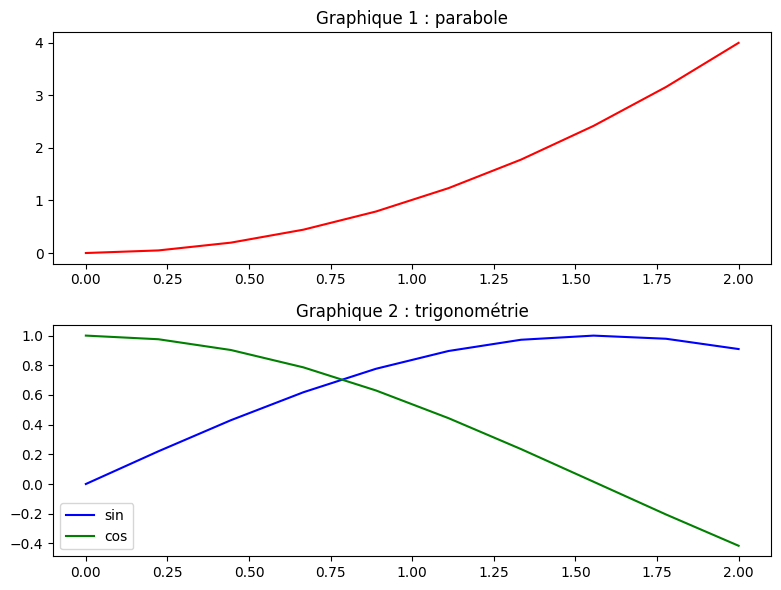

In [ ]:
plt.figure(figsize=(8, 6))
plt.subplot(2, 1, 1)  # 2 lignes, 1 colonne, case n°1
plt.plot(x, y, color='red')
plt.title('Graphique 1 : parabole')
plt.subplot(2, 1, 2)  # case n°2
plt.plot(x, np.sin(x), color='blue',  label='sin')
plt.plot(x, np.cos(x), color='green', label='cos')
plt.title('Graphique 2 : trigonométrie')
plt.legend()
plt.tight_layout()   # indispensable, voir ci-dessous
plt.show()

### Piège n°3 : les titres qui se chevauchent

Sans `plt.tight_layout()`, le titre du graphique du bas vient se superposer à
l'axe du graphique du haut. Matplotlib ne réajuste pas les espacements tout seul.

`tight_layout()` recalcule les marges pour que tout tienne. À appeler juste avant
`show()`, systématiquement, dès qu'il y a plus d'un graphique.

À tester : commente la ligne `plt.tight_layout()` et relance la cellule.

## 6. L'approche orientée objet : subplots

Jusqu'ici on a utilisé l'interface `plt.`, où chaque commande s'applique à une
figure courante implicite. C'est rapide à écrire, mais dès que la figure se
complique, on ne sait plus très bien sur quoi on agit.

L'approche orientée objet rend tout explicite. Elle repose sur une seule
fonction :

```python
fig, ax = plt.subplots()
```

Elle renvoie deux objets :

- `fig`, la figure entière, c'est-à-dire le cadre, ce qu'on enregistre
- `ax`, les axes, c'est-à-dire la zone de tracé elle-même

Attention au nom : `subplots` avec un s n'a rien à voir avec `subplot` sans s,
vu à la section précédente. C'est une confusion classique.

Les méthodes changent légèrement de nom au passage : `plt.title()` devient
`ax.set_title()`, `plt.xlabel()` devient `ax.set_xlabel()`. La règle est simple,
on préfixe par `set_`.

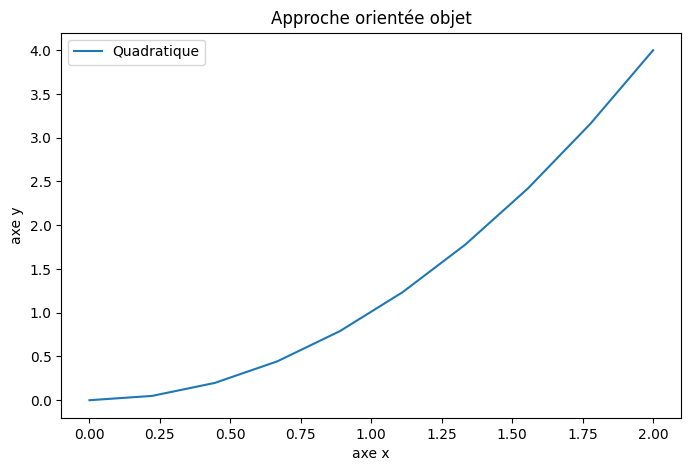

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y, label='Quadratique')
ax.set_title('Approche orientée objet')
ax.set_xlabel('axe x')
ax.set_ylabel('axe y')
ax.legend()
plt.show()

### Une grille d'axes : que contient ax ?

Quand on demande plusieurs cases, `ax` n'est plus un objet unique mais un tableau
NumPy d'objets. Autant le vérifier plutôt que le supposer, c'est le réflexe à
prendre chaque fois qu'on ne sait pas ce que contient une variable.

Type de ax  : <class 'numpy.ndarray'>
Forme de ax : (2,)


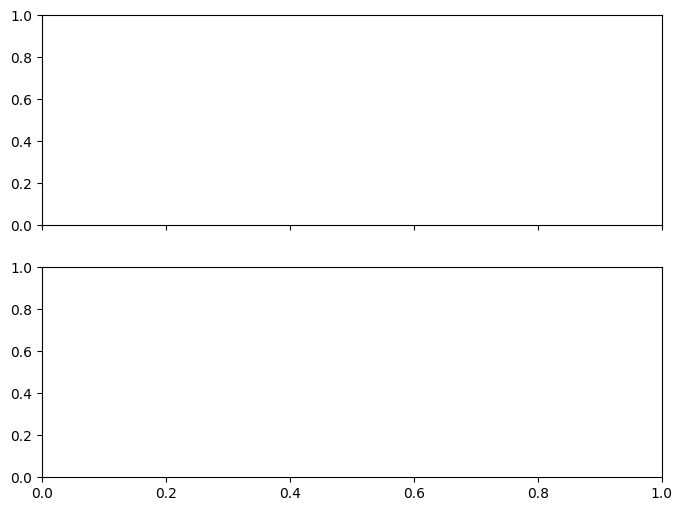

In [ ]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 6))
print("Type de ax  :", type(ax))
print("Forme de ax :", ax.shape)

On obtient un `numpy.ndarray` de forme `(2,)`.

C'est pour cette raison que `ax.plot(x, y)` échoue ici, avec le message
`AttributeError: 'numpy.ndarray' object has no attribute 'plot'`. Un tableau
NumPy n'a pas de méthode `plot`, il faut d'abord sélectionner une case avec
`ax[0]` ou `ax[1]`.

À retenir :

| Appel | Ce que contient `ax` | Accès |
|---|---|---|
| `plt.subplots()` | un seul objet Axes | `ax.plot(...)` |
| `plt.subplots(2, 1)` | tableau de forme `(2,)` | `ax[0].plot(...)` |
| `plt.subplots(2, 3)` | tableau de forme `(2, 3)` | `ax[0, 1].plot(...)` |

L'argument `sharex=True` fait partager le même axe horizontal à tous les
graphiques : ils se zooment ensemble et l'axe n'est affiché qu'en bas. Pratique
pour comparer des courbes qui ont la même échelle en x.

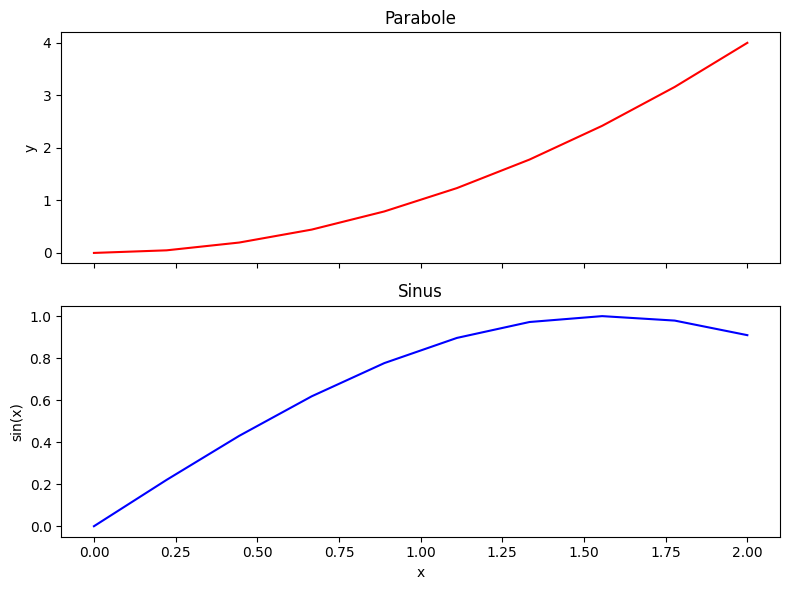

In [ ]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 6))
ax[0].plot(x, y, color='red')
ax[0].set_title('Parabole')
ax[0].set_ylabel('y')
ax[1].plot(x, np.sin(x), color='blue')
ax[1].set_title('Sinus')
ax[1].set_xlabel('x') # une seule fois : l'axe x est partagé
ax[1].set_ylabel('sin(x)')
plt.tight_layout()
plt.show()

À tester : remplace `sharex=True` par `sharey=True`, puis essaie une grille
`2, 2` et accède aux cases avec `ax[0, 0]`, `ax[0, 1]`, et ainsi de suite.

## 7. Aller plus loin : les graphiques utiles en machine learning

Cette section sort du cours de base. Ce sont les quatre outils qu'on utilise
réellement au quotidien quand on travaille sur des données.

### 7.1 scatter avec des couleurs par classe

L'argument `c` de `scatter` accepte non seulement une couleur unique, mais aussi
un tableau de valeurs. Matplotlib attribue alors une couleur différente à chaque
valeur, ce qui permet de visualiser un jeu de données de classification, chaque
couleur représentant une classe.

L'argument `s` fonctionne de la même façon pour la taille des points, ce qui
permet d'encoder une troisième variable.

In [ ]:
print(plt.cm.viridis(0.0))   # (0.267, 0.004, 0.329, 1.0) violet foncé
print(plt.cm.viridis(0.5))   # (0.127, 0.566, 0.550, 1.0) turquoise
print(plt.cm.viridis(1.0))   # (0.993, 0.906, 0.143, 1.0) jaune

(np.float64(0.267004), np.float64(0.004874), np.float64(0.329415), np.float64(1.0))
(np.float64(0.127568), np.float64(0.566949), np.float64(0.550556), np.float64(1.0))
(np.float64(0.993248), np.float64(0.906157), np.float64(0.143936), np.float64(1.0))


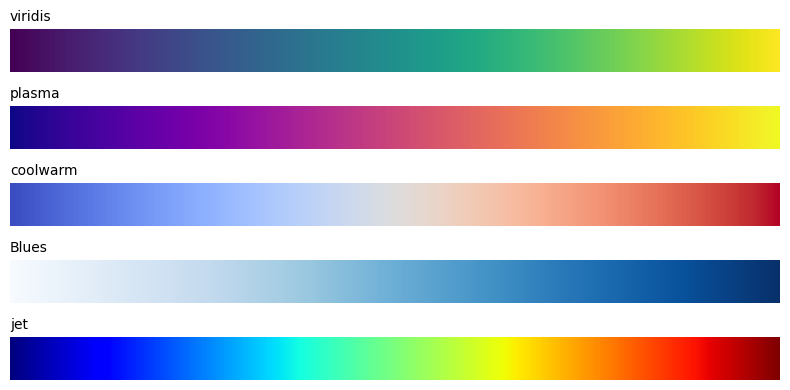

In [ ]:
palettes = ['viridis', 'plasma', 'coolwarm', 'Blues', 'jet']
gradient = np.linspace(0, 1, 256).reshape(1, -1)

fig, ax = plt.subplots(len(palettes), 1, figsize=(8, 4))

for i, nom in enumerate(palettes):
    ax[i].imshow(gradient, aspect='auto', cmap=nom)
    ax[i].set_title(nom, fontsize=10, loc='left')
    ax[i].axis('off')

plt.tight_layout()
plt.show()

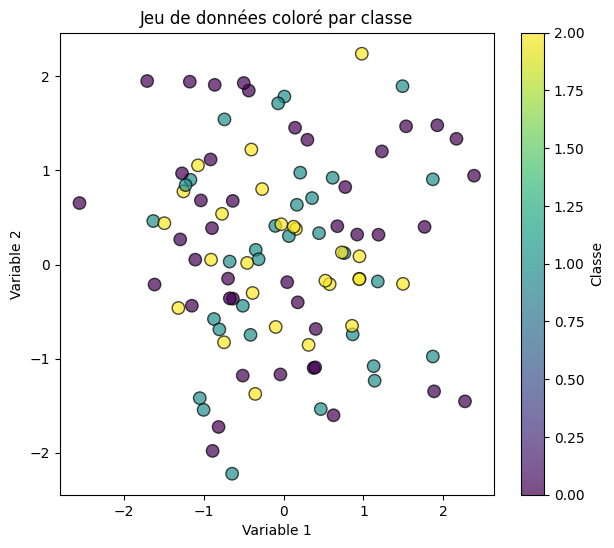

In [ ]:
# Un faux jeu de données : 100 individus, 2 variables, 3 classes
np.random.seed(0) # même tirage à chaque exécution
X = np.random.randn(100, 2) # 1 ligne = 1 individu, 1 colonne = 1 variable
labels = np.random.randint(0, 3, 100)  # une classe (0, 1 ou 2) par individu

plt.figure(figsize=(7, 6))
plt.scatter(
    X[:, 0], # toutes les lignes, colonne 0 pour abscisses
    X[:, 1], # toutes les lignes, colonne 1 pour ordonnées
    c=labels,# un tableau, donc une couleur par classe
    s=80, # taille des points
    cmap='viridis', # règle de conversion valeur -> couleur
    alpha=0.7, # transparence : les superpositions ressortent
    edgecolors='black',  # contour, pour détacher les points du fond
)

plt.colorbar(label='Classe') # échelle des couleurs
plt.title("Jeu de données coloré par classe")
plt.xlabel('Variable 1')
plt.ylabel('Variable 2')
plt.show()

### 7.2 hist : la distribution d'une variable

Un histogramme découpe les valeurs en intervalles, appelés *bins*, et compte
combien d'observations tombent dans chacun. C'est le premier graphique à faire
quand on découvre un jeu de données : il révèle immédiatement l'échelle, les
valeurs aberrantes et la forme de la distribution.

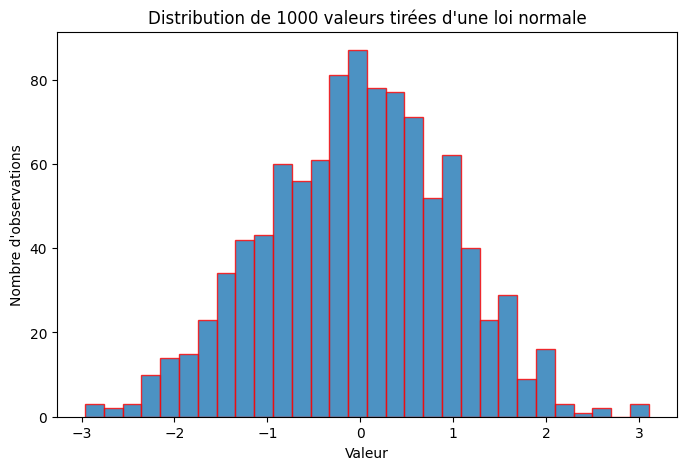

In [ ]:
donnees = np.random.randn(1000)
plt.figure(figsize=(8, 5))
plt.hist(donnees, bins=30, edgecolor='red', alpha=0.8)
plt.title("Distribution de 1000 valeurs tirées d'une loi normale")
plt.xlabel('Valeur')
plt.ylabel("Nombre d'observations")
plt.show()

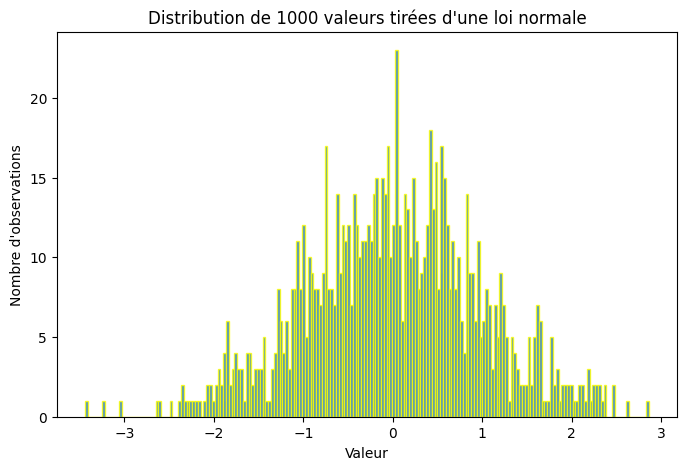

In [ ]:
donnees = np.random.randn(1000)
plt.figure(figsize=(8, 5))
plt.hist(donnees, bins=200, edgecolor='yellow', alpha=0.8)
plt.title("Distribution de 1000 valeurs tirées d'une loi normale")
plt.xlabel('Valeur')
plt.ylabel("Nombre d'observations")
plt.show()

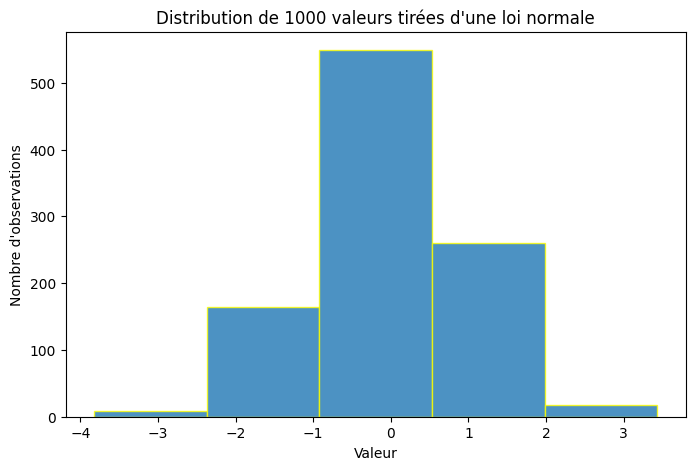

In [ ]:
donnees = np.random.randn(1000)
plt.figure(figsize=(8, 5))
plt.hist(donnees, bins=5, edgecolor='yellow', alpha=0.8)
plt.title("Distribution de 1000 valeurs tirées d'une loi normale")
plt.xlabel('Valeur')
plt.ylabel("Nombre d'observations")
plt.show()

À tester : fais varier `bins` avec 5, 30 puis 200. Trop peu de bins masque la
forme de la distribution, trop de bins la noie dans le bruit. Il n'existe pas de
valeur correcte universelle, c'est un choix, et il influence l'interprétation.

### 7.3 imshow : afficher une matrice ou une image

`imshow` affiche un tableau à deux dimensions sous forme d'image, chaque valeur
devenant un pixel coloré. On s'en sert pour afficher de vraies images, mais aussi
des matrices de corrélation ou des matrices de confusion.

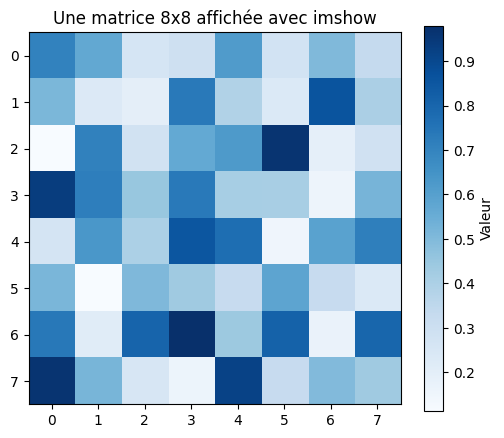

In [ ]:
matrice = np.random.rand(8, 8) # 64 valeurs entre 0 et 1, en 8 lignes x 8 colonnes
plt.figure(figsize=(6, 5))
plt.imshow(matrice, cmap='Blues') # chaque case devient un pixel coloré
plt.colorbar(label='Valeur')  # échelle des couleurs
plt.title("Une matrice 8x8 affichée avec imshow")
plt.show()

In [ ]:
print(plt.colormaps())

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

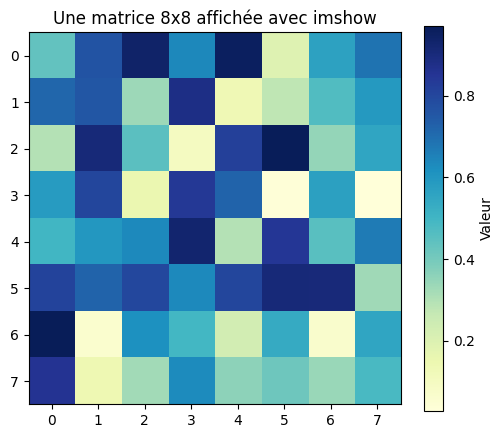

In [ ]:
matrice = np.random.rand(8, 8) # 64 valeurs entre 0 et 1, en 8 lignes x 8 colonnes
plt.figure(figsize=(6, 5))
plt.imshow(matrice, cmap='YlGnBu') # chaque case devient un pixel coloré
plt.colorbar(label='Valeur')  # échelle des couleurs
plt.title("Une matrice 8x8 affichée avec imshow")
plt.show()

### 7.4 Changer de style en une ligne

`plt.style.use()` modifie l'apparence de tous les graphiques qui suivent. Utile
pour rendre un notebook plus lisible sans toucher au reste du code.

In [ ]:
print(plt.style.available)  # la liste des styles disponibles

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


29 styles


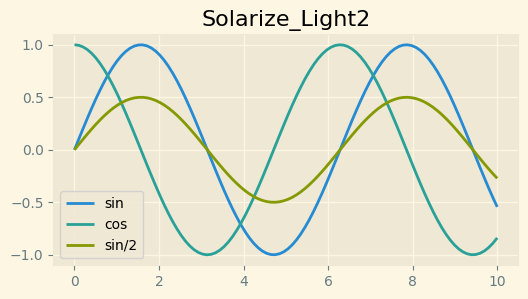

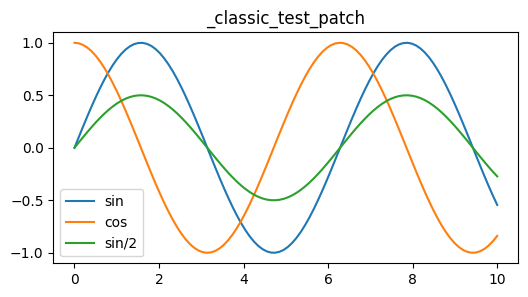

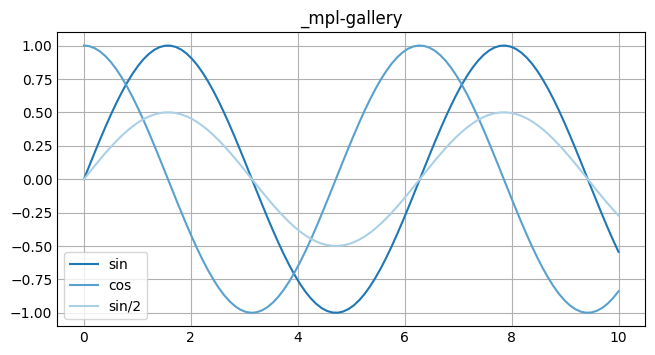

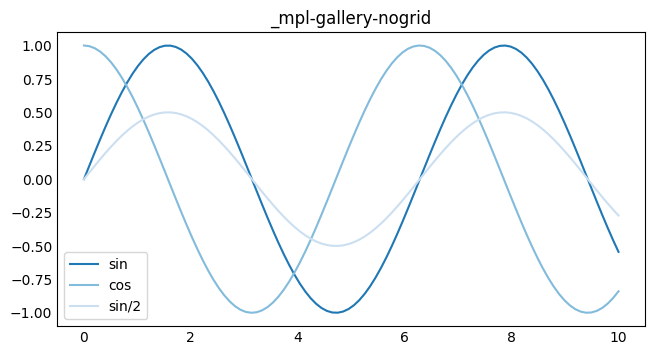

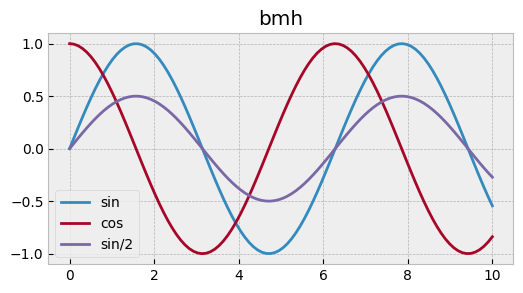

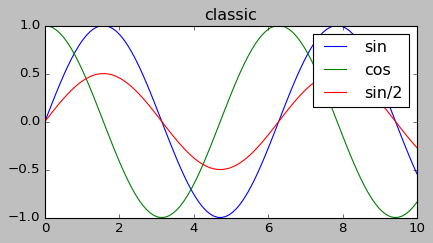

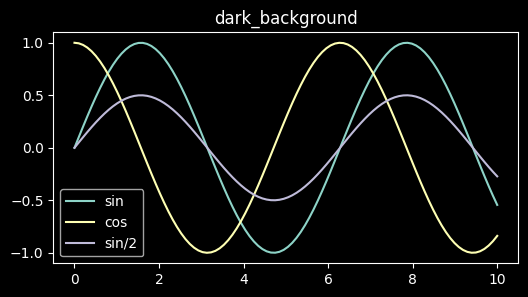

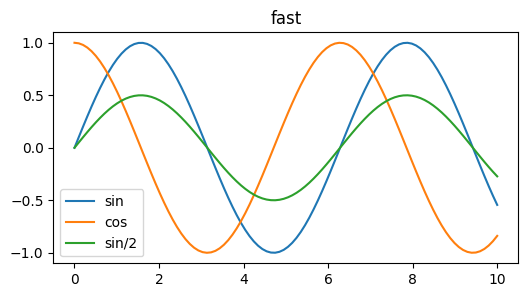

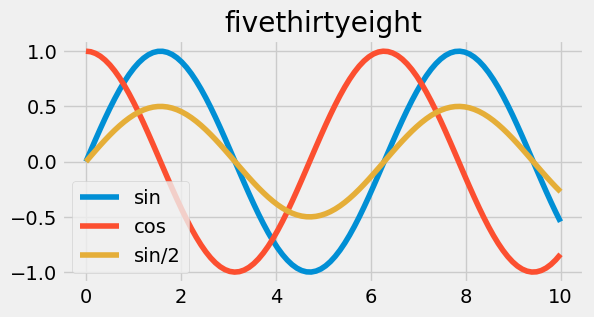

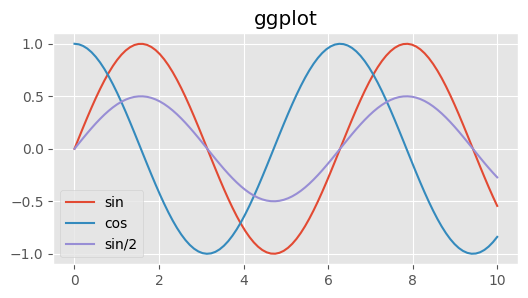

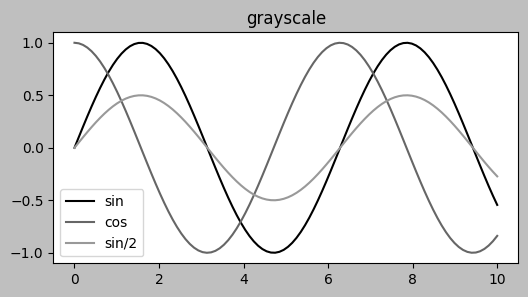

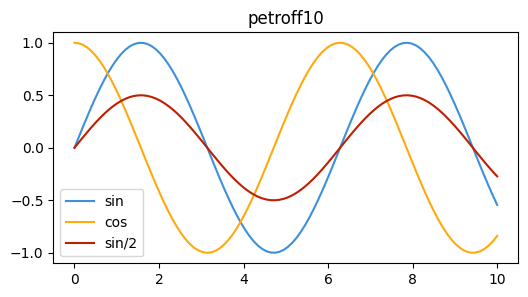

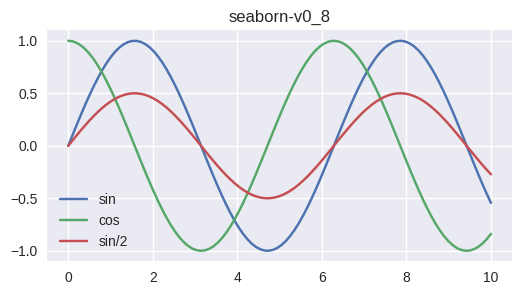

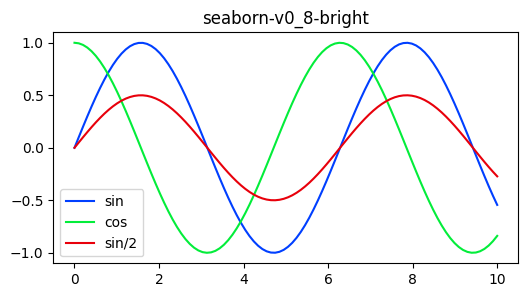

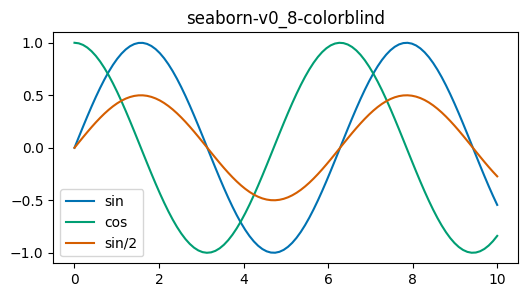

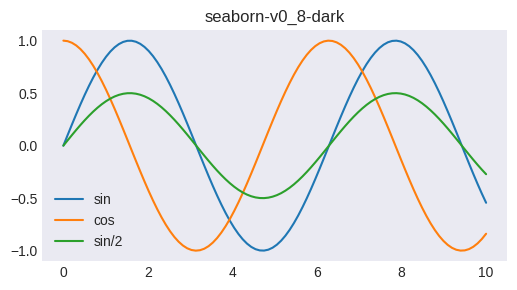

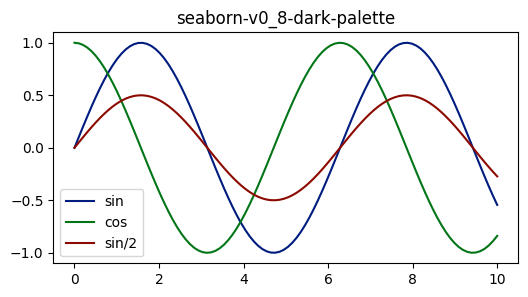

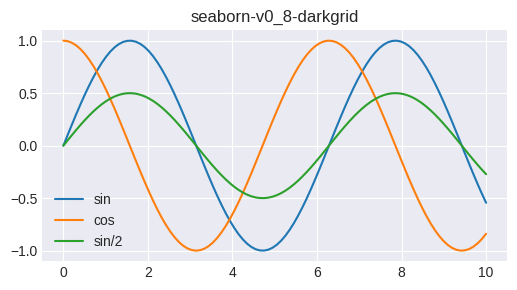

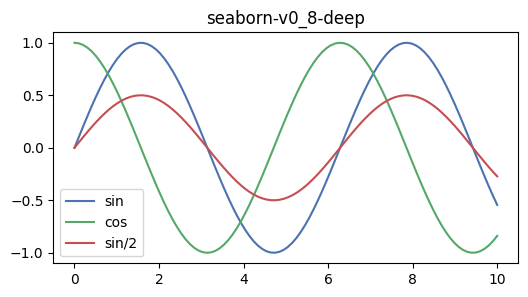

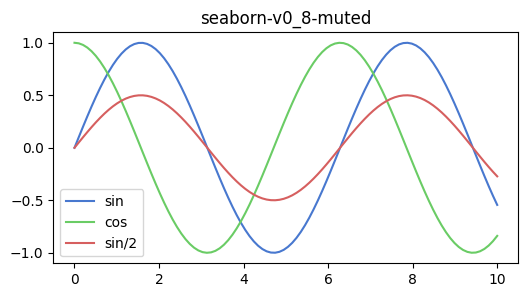

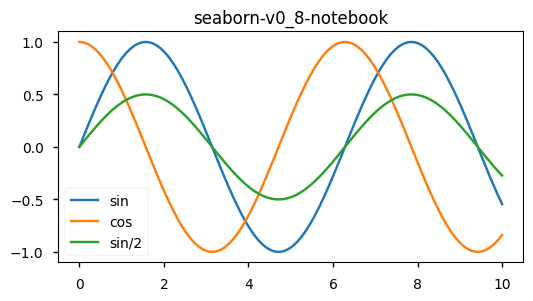

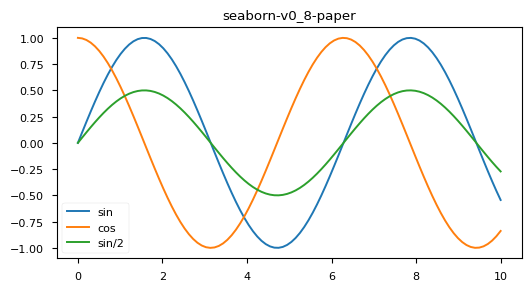

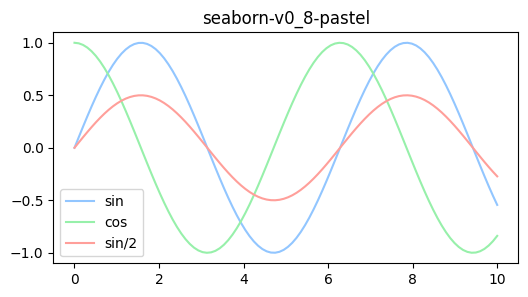

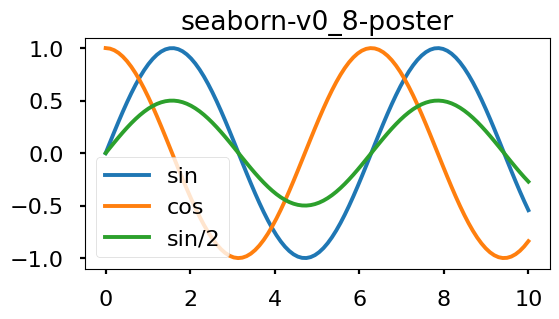

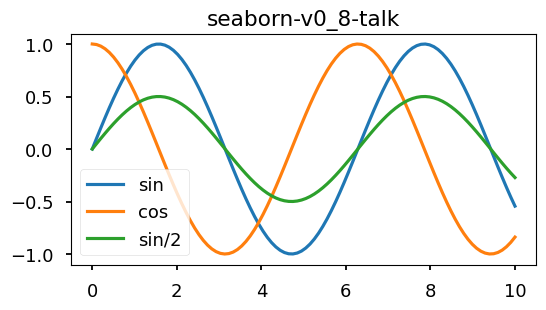

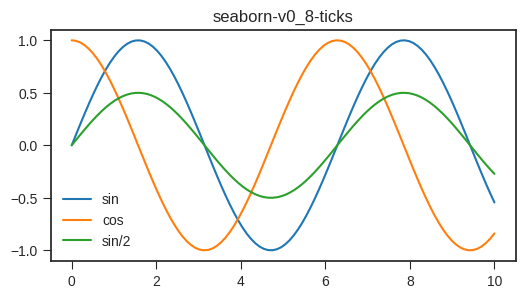

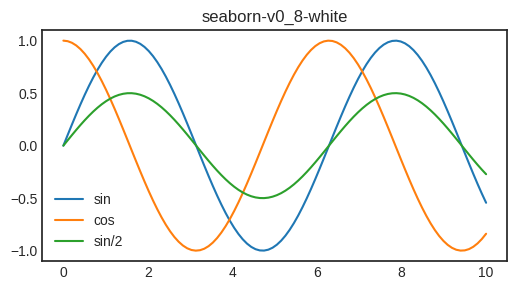

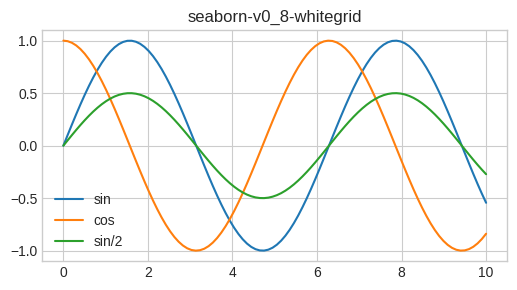

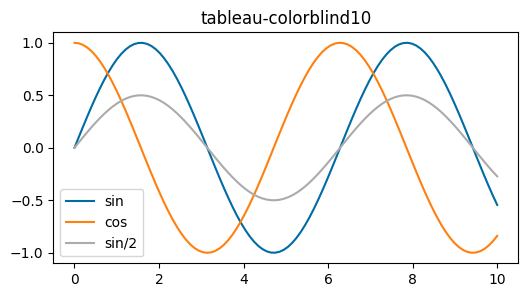

In [ ]:
styles = plt.style.available  # tous les styles disponibles
print(len(styles), "styles")

x = np.linspace(0, 10, 100)

for nom in styles:
    with plt.style.context(nom):  # applique le style, puis le retire à la sortie du bloc
        plt.figure(figsize=(6, 3))
        plt.plot(x, np.sin(x), label='sin')
        plt.plot(x, np.cos(x), label='cos')
        plt.plot(x, np.sin(x) / 2, label='sin/2')
        plt.legend()
        plt.title(nom)
        plt.show()

## 8. Mémo récapitulatif

### La structure type d'une figure

```python
plt.figure(figsize=(8, 5))
plt.plot(x, y, label='...')
plt.title('...')
plt.xlabel('...')
plt.ylabel('...')
plt.legend()
plt.savefig('fichier.png', dpi=150, bbox_inches='tight')   # avant show
plt.show()
```

### Les trois pièges à connaître

| Symptôme | Cause | Solution |
|---|---|---|
| Le fichier PNG enregistré est vide | `savefig` appelé après `show` | inverser les deux |
| Pas de légende malgré les `label=` | `legend()` oublié | ajouter `plt.legend()` |
| Les titres se chevauchent | espacements non recalculés | ajouter `plt.tight_layout()` |

### Les deux interfaces

| | Interface `plt.` | Interface orientée objet |
|---|---|---|
| Créer | `plt.figure()` | `fig, ax = plt.subplots()` |
| Tracer | `plt.plot(x, y)` | `ax.plot(x, y)` |
| Titre | `plt.title('...')` | `ax.set_title('...')` |
| Axe x | `plt.xlabel('...')` | `ax.set_xlabel('...')` |

La première est plus rapide à écrire et convient à l'exploration. La seconde est
recommandée par la documentation officielle dès que la figure se complique,
parce qu'elle rend explicite l'objet sur lequel on agit.

## Annexe : les couleurs dans Matplotlib

Tout au long de ce notebook, les couleurs ont été indiquées par leur nom :
`'blue'`, `'red'`, `'green'`. C'est le plus simple, mais ce n'est qu'une des
notations acceptées par Matplotlib, et pas la plus souple.

### Les cinq façons d'indiquer une couleur

| Notation | Exemple | Remarque |
|---|---|---|
| Nom CSS4 | `'mediumseagreen'` | 148 noms disponibles |
| Code hexadécimal | `'#2ecc71'` | 16 millions de couleurs |
| Tuple RGB | `(0.18, 0.8, 0.44)` | trois valeurs entre 0 et 1 |
| Abréviation | `'g'` | 8 couleurs seulement : b, g, r, c, m, y, k, w |
| Niveau de gris | `'0.5'` | une chaîne entre `'0'` (noir) et `'1'` (blanc) |

Les cinq lignes ci-dessous produisent donc à peu près le même vert :

```python
plt.plot(x, y, color='mediumseagreen')
plt.plot(x, y, color='#2ecc71')
plt.plot(x, y, color=(0.18, 0.80, 0.44))
plt.plot(x, y, color='g')
```

### Comment lire un code hexadécimal

Le format s'écrit `#RRGGBB` : deux caractères par canal, en base 16, donc de
`00` (rien) à `ff` (le maximum, soit 255).

Pour `#2ecc71` : `2e` vaut 46 de rouge, `cc` vaut 204 de vert, `71` vaut 113 de
bleu. Le vert domine largement, d'où la couleur obtenue.

On peut ajouter deux caractères supplémentaires pour la transparence, ce qui
donne `#2ecc7180` pour un vert à moitié transparent.

### Retrouver les couleurs disponibles

Les couleurs nommées sont stockées dans des dictionnaires, accessibles depuis le
module `matplotlib.colors`. Chaque nom y est associé à son code hexadécimal.

```python
import matplotlib.colors as mcolors

print(len(mcolors.CSS4_COLORS), "couleurs nommées")
print(mcolors.CSS4_COLORS['tomato'])   # affiche #FF6347
print(mcolors.TABLEAU_COLORS)          # les 10 couleurs du cycle par défaut
```

Il existe également `mcolors.XKCD_COLORS`, qui rassemble 949 couleurs dont les
noms proviennent d'un sondage public. Plus anecdotique qu'utile.

### En pratique

Pour un notebook de cours, les noms suffisent et se relisent bien. Pour un
rapport ou une présentation, le code hexadécimal permet de respecter une charte
graphique précise.

Une troisième voie, souvent la meilleure, consiste à piocher dans une palette
existante plutôt que de choisir ses couleurs une par une :

```python
couleurs = plt.cm.viridis(np.linspace(0, 1, 5))   # 5 couleurs de la palette viridis
```

Les couleurs obtenues sont cohérentes entre elles, restent lisibles en noir et
blanc, et fonctionnent pour la plupart des daltonismes. C'est d'ailleurs la
raison pour laquelle `viridis` est la palette par défaut de Matplotlib depuis la
version 2.0.

In [ ]:
import matplotlib.colors as mcolors

In [ ]:
# Les 148 couleurs CSS4 : un dictionnaire {nom: code hexadécimal}
print(len(mcolors.CSS4_COLORS), "couleurs disponibles")

148 couleurs disponibles


In [ ]:
print(mcolors.CSS4_COLORS['tomato']) #FF6347

#FF6347


In [ ]:
print(mcolors.CSS4_COLORS['blue'])

#0000FF


In [ ]:
print(mcolors.CSS4_COLORS['orange'])


#FFA500


In [ ]:
# Les 10 couleurs du cycle par défaut de Matplotlib
print(mcolors.TABLEAU_COLORS)

{'tab:blue': '#1f77b4', 'tab:orange': '#ff7f0e', 'tab:green': '#2ca02c', 'tab:red': '#d62728', 'tab:purple': '#9467bd', 'tab:brown': '#8c564b', 'tab:pink': '#e377c2', 'tab:gray': '#7f7f7f', 'tab:olive': '#bcbd22', 'tab:cyan': '#17becf'}


In [ ]:
# Voir les 20 premières, triées par nom
for nom, hexa in list(mcolors.CSS4_COLORS.items())[:20]:
    print(f"{nom:<20} {hexa}")

aliceblue            #F0F8FF
antiquewhite         #FAEBD7
aqua                 #00FFFF
aquamarine           #7FFFD4
azure                #F0FFFF
beige                #F5F5DC
bisque               #FFE4C4
black                #000000
blanchedalmond       #FFEBCD
blue                 #0000FF
blueviolet           #8A2BE2
brown                #A52A2A
burlywood            #DEB887
cadetblue            #5F9EA0
chartreuse           #7FFF00
chocolate            #D2691E
coral                #FF7F50
cornflowerblue       #6495ED
cornsilk             #FFF8DC
crimson              #DC143C


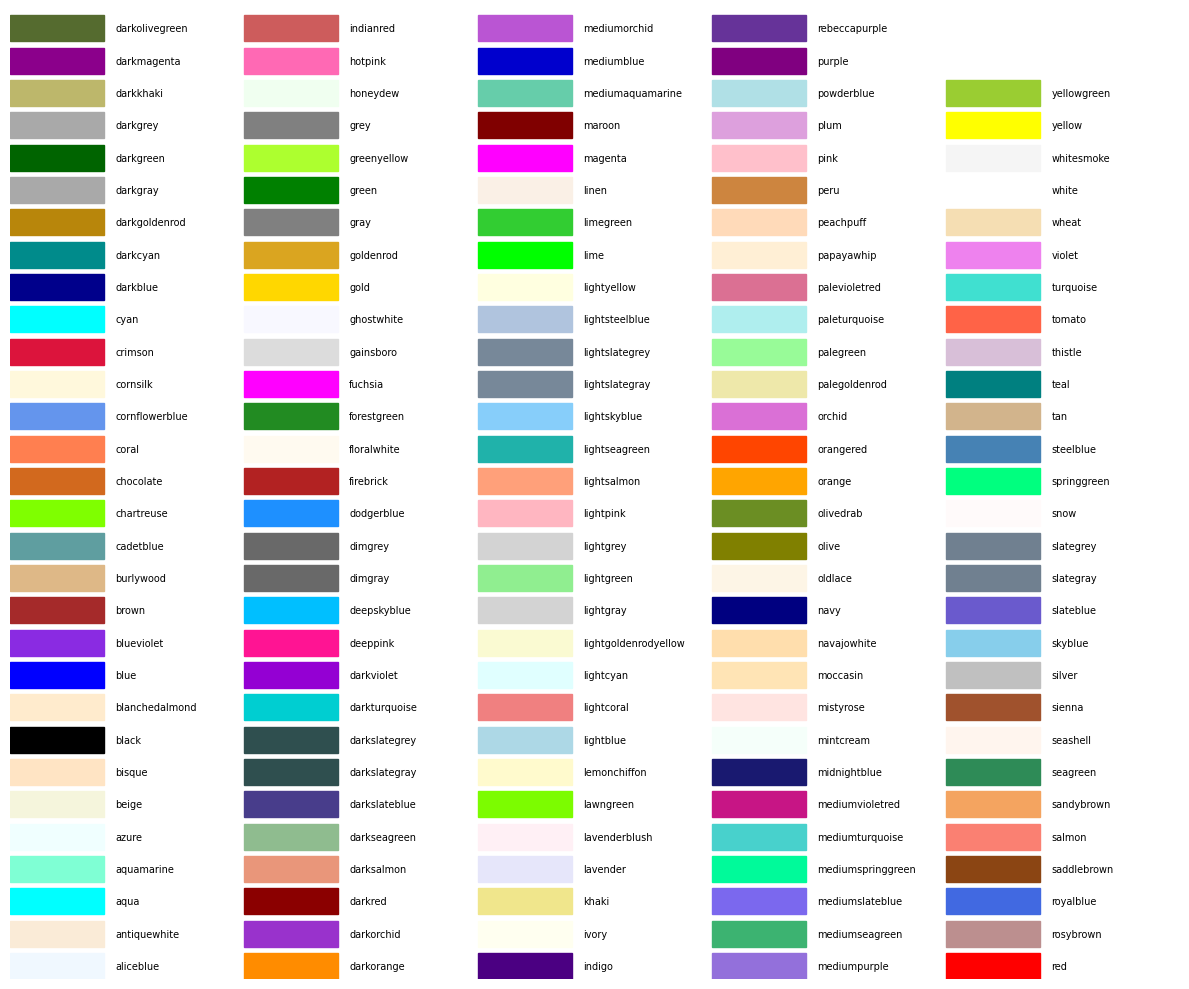

In [ ]:
noms = sorted(mcolors.CSS4_COLORS) # les 148 noms, triés par ordre alphabétique

fig, ax = plt.subplots(figsize=(12, 10))

for i, nom in enumerate(noms):
    ligne, colonne = i % 30, i // 30 # 30 par colonne : reste et quotient
    ax.add_patch(plt.Rectangle(
        (colonne, ligne), # coin bas-gauche du rectangle
        0.4, 0.8, # largeur, hauteur
        color=mcolors.CSS4_COLORS[nom])) # la couleur elle-même
    ax.text(colonne + 0.45, ligne + 0.4, # texte juste à droite du rectangle
            nom, fontsize=7, va='center') # va = alignement vertical

ax.set_xlim(0, 5) # 5 colonnes de large
ax.set_ylim(0, 30) # 30 lignes de haut
ax.axis('off') # pas d'axes ni de graduations
plt.tight_layout()
plt.show()

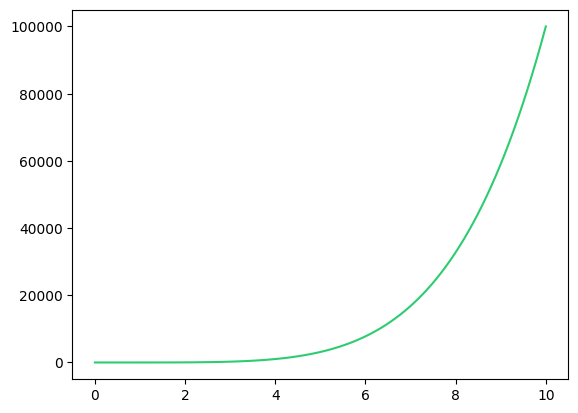

In [ ]:
x = np.linspace(0,10,100)
y = x**5
plt.plot(x, y, color='#2ecc71') # hexadécimal

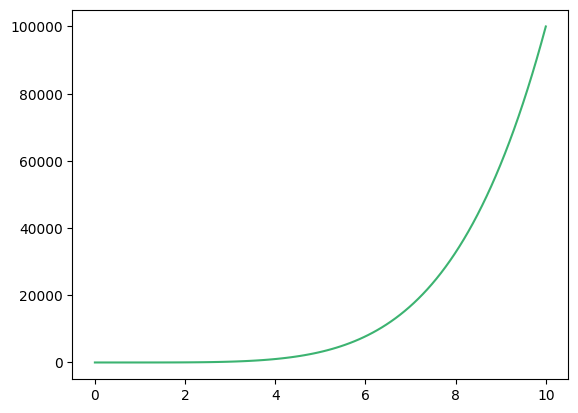

In [ ]:
plt.plot(x, y, color='mediumseagreen') # nom CSS4

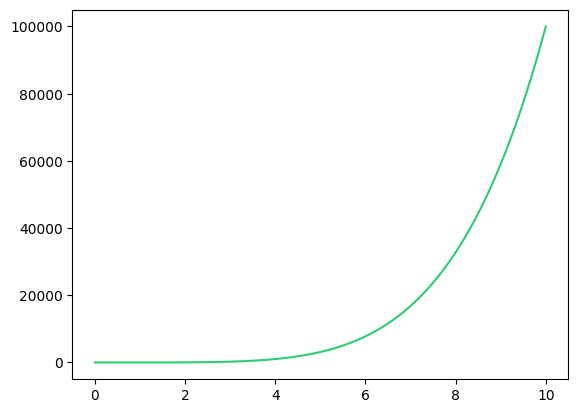

In [ ]:
plt.plot(x, y, color=(0.18, 0.8, 0.44)) # tuple RGB entre 0 et 1

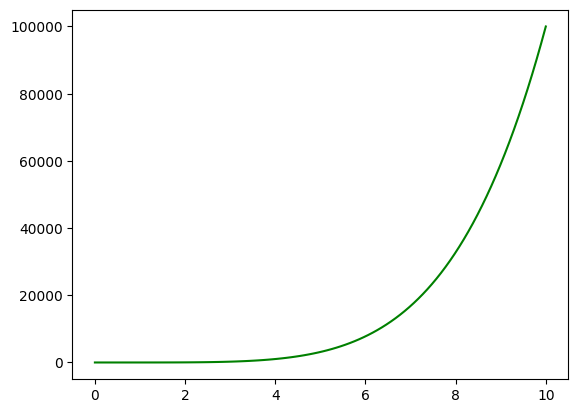

In [ ]:
plt.plot(x, y, color='g') # abréviation (8 couleurs seulement)

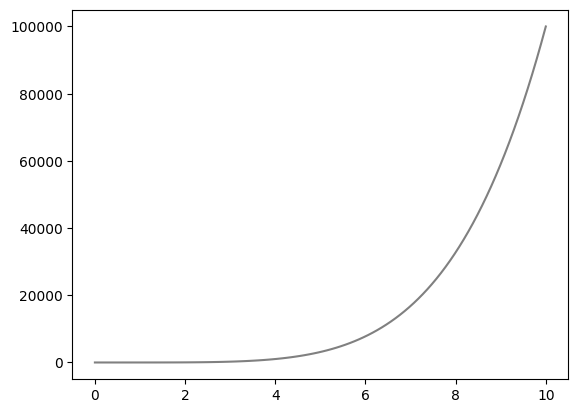

In [ ]:
plt.plot(x, y, color='0.5') # niveau de gris, chaîne entre '0' et '1'

## 9. Exercices

**Exercice 1, la figure complète**

Trace sur une même figure les fonctions `sin(x)`, `cos(x)` et `sin(x)*cos(x)`
pour `x` allant de 0 à 4π avec 200 points. Chaque courbe doit avoir une couleur
et un style de ligne différents. La figure doit comporter un titre, des noms
d'axes et une légende, puis être enregistrée en PNG.

**Exercice 2, la grille**

Crée une grille de 2×2 graphiques avec l'interface orientée objet, affichant `x`,
`x²`, `x³` et `√x`. Donne un titre à chaque case, ainsi qu'un titre général à la
figure entière. Cherche `fig.suptitle` dans la documentation.

**Exercice 3, le nuage de points**

Génère 200 points aléatoires en deux dimensions, répartis en deux classes.
Affiche-les avec `scatter` en coloriant selon la classe, et fais varier la taille
des points selon leur distance à l'origine.

## Pour continuer

La galerie officielle est la meilleure ressource, chaque exemple étant
accompagné de son code complet : matplotlib.org/stable/gallery

La bibliothèque Seaborn est construite au-dessus de Matplotlib et simplifie
beaucoup les graphiques statistiques. Tout ce qui a été vu ici y reste valable.

### Exerice 1

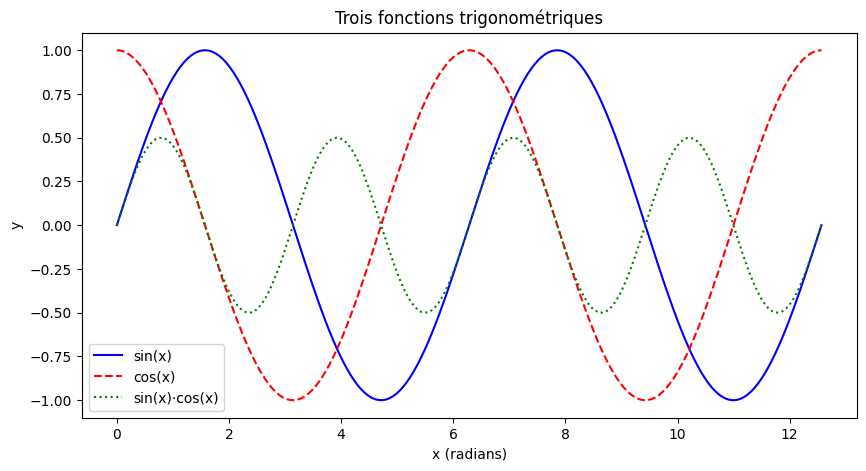

In [ ]:
x = np.linspace(0, 4 * np.pi, 200)

plt.figure(figsize=(10, 5))

plt.plot(x, np.sin(x), color='blue', linestyle='solid', label='sin(x)')
plt.plot(x, np.cos(x), color='red', linestyle='dashed', label='cos(x)')
plt.plot(x, np.sin(x) * np.cos(x), color='green', linestyle='dotted', label='sin(x)·cos(x)')

plt.title('Trois fonctions trigonométriques')
plt.xlabel('x (radians)')
plt.ylabel('y')
plt.legend()

plt.savefig('exercice1.png', dpi=150, bbox_inches='tight')
plt.show()


Deux points méritent l'attention.

Le nombre de points, d'abord. Avec 200 points sur un intervalle de 4π, les
courbes sont lisses. Essaie avec 20 points : les oscillations deviennent
anguleuses et le sinus finit par ressembler à autre chose. C'est le piège vu en
section 1, et il se manifeste d'autant plus que la fonction oscille vite.

L'ordre des appels, ensuite. `savefig` vient avant `show`, comme toujours. Et
`legend()` est appelé après les trois `plot`, car il faut que les labels
existent au moment où la légende se construit.

La troisième courbe, `sin(x)·cos(x)`, vaut la peine d'être regardée : elle
oscille deux fois plus vite que les deux autres, avec une amplitude divisée par
deux. C'est la formule `sin(2x)/2`, qu'on retrouve ici visuellement.

### Exerice 2

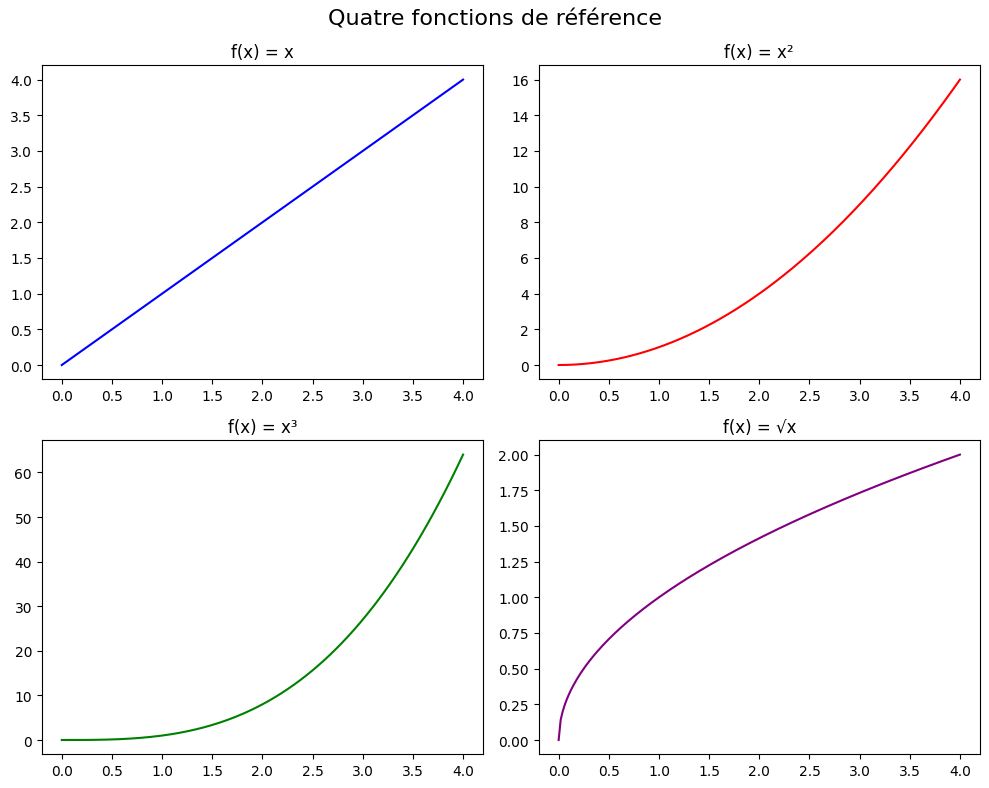

In [ ]:
x = np.linspace(0, 4, 200)

fig, ax = plt.subplots(2, 2, figsize=(10, 8))

ax[0, 0].plot(x, x, color='blue')
ax[0, 0].set_title('f(x) = x')

ax[0, 1].plot(x, x**2, color='red')
ax[0, 1].set_title('f(x) = x²')

ax[1, 0].plot(x, x**3, color='green')
ax[1, 0].set_title('f(x) = x³')

ax[1, 1].plot(x, np.sqrt(x), color='purple')
ax[1, 1].set_title('f(x) = √x')

fig.suptitle('Quatre fonctions de référence', fontsize=16)

plt.tight_layout()
plt.show()

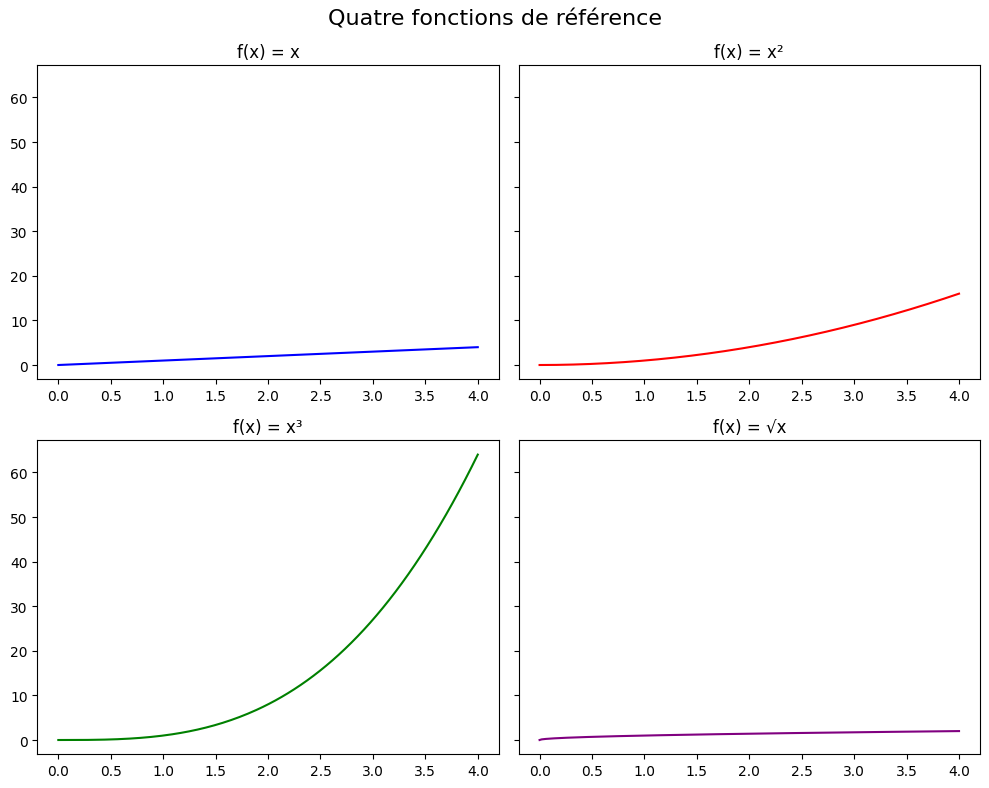

In [ ]:
x = np.linspace(0, 4, 200)

fig, ax = plt.subplots(2, 2, figsize=(10, 8), sharey = True )

ax[0, 0].plot(x, x, color='blue')
ax[0, 0].set_title('f(x) = x')

ax[0, 1].plot(x, x**2, color='red')
ax[0, 1].set_title('f(x) = x²')

ax[1, 0].plot(x, x**3, color='green')
ax[1, 0].set_title('f(x) = x³')

ax[1, 1].plot(x, np.sqrt(x), color='purple')
ax[1, 1].set_title('f(x) = √x')

fig.suptitle('Quatre fonctions de référence', fontsize=16)

plt.tight_layout()
plt.show()

Avec une grille `2, 2`, le tableau `ax` a deux dimensions. On accède aux cases
avec deux indices, `ax[ligne, colonne]`, et non plus avec un seul comme dans le
cas `2, 1`. Un `print(ax.shape)` avant de tracer le confirme.

`fig.suptitle` est une méthode de la figure, pas des axes. La distinction est
logique : le titre général concerne l'ensemble, tandis que `set_title` concerne
une case. C'est un des avantages de l'interface orientée objet, on voit
directement à quel niveau on agit.

`tight_layout` est indispensable ici. Sans lui, le titre général se superpose
aux titres de la première ligne.

Une remarque sur les échelles : chaque case a son propre axe vertical, ce qui
rend la comparaison trompeuse. Les quatre courbes semblent avoir des amplitudes
comparables alors que x³ monte à 64 et √x plafonne à 2. Ajoute `sharey=True`
dans `subplots` pour visualiser l'écart réel.

### Exerice 3

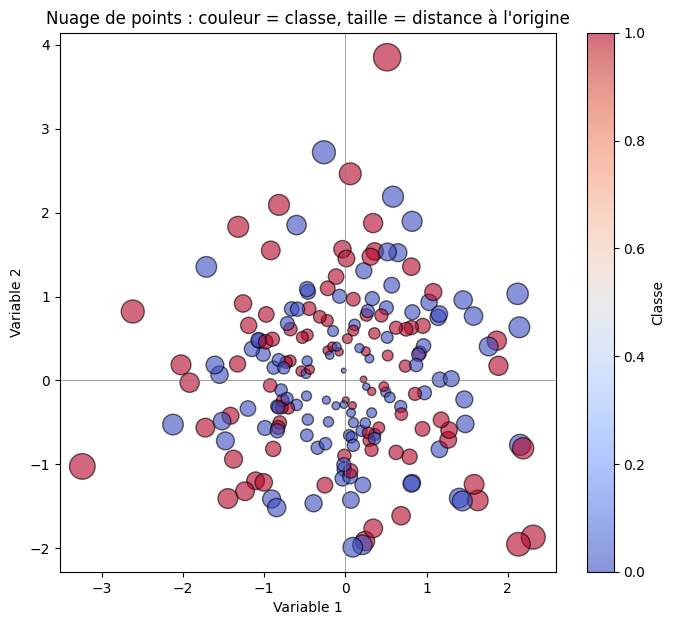

In [ ]:
np.random.seed(42)

X = np.random.randn(200, 2) # 200 points, 2 dimensions
labels = np.random.randint(0, 2, 200) # 2 classes : 0 ou 1

# Distance de chaque point à l'origine, via le théorème de Pythagore
distances = np.sqrt(X[:, 0]**2 + X[:, 1]**2)
tailles = distances * 100 # facteur d'échelle pour la lisibilité

plt.figure(figsize=(8, 7))
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    s=tailles,
    cmap='coolwarm',
    alpha=0.6,
    edgecolors='black',
)

plt.colorbar(label='Classe')
plt.title('Nuage de points : couleur = classe, taille = distance à l\'origine')
plt.xlabel('Variable 1')
plt.ylabel('Variable 2')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.show()

Le calcul des distances se fait sans boucle : `X[:, 0]**2` élève au carré toute
la première colonne d'un coup, et `np.sqrt` s'applique à tout le tableau
résultant. C'est la vectorisation NumPy, et sur 200 points la différence de
vitesse avec une boucle Python est déjà mesurable. Essaie avec `%timeit` sur un
million de points, l'écart devient spectaculaire.

Le facteur 100 appliqué aux tailles n'a rien de scientifique. L'argument `s`
s'exprime en points au carré, et les distances brutes valent ici entre 0 et 3
environ, ce qui donnerait des points invisibles. Ce genre d'ajustement empirique
est fréquent, et c'est une raison de plus de toujours indiquer dans le titre ou
la légende ce que la taille représente.

`axhline` et `axvline` tracent les axes passant par l'origine. Ce n'était pas
demandé, mais comme la taille encode ici la distance à l'origine, marquer ce
point de référence rend le graphique bien plus lisible : on voit les petits
points se concentrer au centre.

Un point d'honnêteté sur ce graphique : les classes ont été tirées au hasard,
elles ne correspondent à aucune structure dans les données. Les deux couleurs
sont donc parfaitement mélangées. Sur un vrai jeu de données, c'est justement ce
qu'on cherche à observer : si les couleurs se séparent visuellement, un modèle
simple suffira probablement. Si elles se mélangent comme ici, il faudra soit un
modèle plus complexe, soit d'autres variables.